<a href="https://colab.research.google.com/github/coinblum01-wq/trucweb/blob/main/NguyenTrongTruc_2474802016707_Lab5" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nguyễn Trọng Trúc - 2474802016707 - Lab5**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

**Phần 1: Khởi tạo và Đọc dữ liệu**

In [9]:
#1. Import thư viện và đọc dữ liệu
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("ecommerce_sales_data.xlsx")

In [11]:
#2. Hiển thị 7 dòng đầu và 5 dòng cuối
print("--- 7 dòng đầu tiên ---")
print(df.head(7))

print("\n--- 5 dòng cuối cùng ---")
print(df.tail(5))

--- 7 dòng đầu tiên ---
   OrderID        Date CustomerID Product_Category            Product_Name  Quantity  UnitPrice  Discount   Region
0  ORD0001  2025-11-24    CUST027         Clothing                   Jeans         6      93.20      0.12  Central
1  ORD0002  2025-02-27    CUST025      Electronics              Smartphone        10     134.67       NaN    South
2  ORD0003  2025-01-13    CUST025            Books  Machine Learning Intro         9     178.20      0.04    North
3  ORD0004  2025-05-21    CUST002   Home & Kitchen            Coffee Maker         3     199.86      0.01    North
4  ORD0005  2025-05-06    CUST008      Electronics                  Laptop         7     144.85      0.17    North
5  ORD0006  2025-04-25    CUST027      Electronics                  Laptop         3     138.23       NaN  Central
6  ORD0007  2025-03-13    CUST002            Books   Data Science Handbook         1      71.97      0.04    South

--- 5 dòng cuối cùng ---
    OrderID        Date Custom

In [15]:
#3. Thông tin tổng quan
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   OrderID           100 non-null    object 
 1   Date              100 non-null    object 
 2   CustomerID        95 non-null     object 
 3   Product_Category  100 non-null    object 
 4   Product_Name      100 non-null    object 
 5   Quantity          100 non-null    int64  
 6   UnitPrice         100 non-null    float64
 7   Discount          65 non-null     float64
 8   Region            100 non-null    object 
dtypes: float64(2), int64(1), object(6)
memory usage: 7.2+ KB


In [17]:
#4. Thống kê mô tả
df.describe()

,Quantity,UnitPrice,Discount
count,100.000000,100.000000,65.000000
mean,5.150000,153.546200,0.141385
std,2.896794,77.360231,0.079134
min,-5.000000,11.610000,0.010000
25%,3.000000,84.445000,0.080000
50%,5.000000,154.880000,0.150000
75%,7.000000,215.792500,0.210000
max,10.000000,296.490000,0.300000


**Phần 2: Khám phá và Làm sạch dữ liệu**

In [18]:
#1. Kiểm tra giá trị thiếu
print(df.isna().sum())

OrderID              0
Date                 0
CustomerID           5
Product_Category     0
Product_Name         0
Quantity             0
UnitPrice            0
Discount            35
Region               0
dtype: int64


In [19]:
#2. Xử lý giá trị thiếu cột Discount
df["Discount"] = df["Discount"].fillna(0)

In [20]:
#3. Xử lý giá trị thiếu cột CustomerID
df["CustomerID"] = df["CustomerID"].fillna("GUEST")

In [21]:
#4. Kiểm tra lại không còn giá trị thiếu
print(df.isna().sum())

OrderID             0
Date                0
CustomerID          0
Product_Category    0
Product_Name        0
Quantity            0
UnitPrice           0
Discount            0
Region              0
dtype: int64


In [22]:
#5. Chuyển đổi cột Date sang datetime
df["Date"] = pd.to_datetime(df["Date"])
print(df["Date"].dtype)

datetime64[ns]


In [23]:
#6. Kiểm tra và loại bỏ dòng trùng lặp
print("Số dòng trùng lặp:", df.duplicated().sum())
df = df.drop_duplicates()

Số dòng trùng lặp: 0


**Phần 3: Trích xuất và Biến đổi dữ liệu**

In [24]:
#1. Tạo cột Revenue
df["Revenue"] = df["Quantity"] * df["UnitPrice"] * (1 - df["Discount"])

In [44]:
#2. Trích xuất Year
df["Year"] = df["Date"].dt.year
print(df[["Date", "Year"]].head())

        Date  Year
0 2025-11-24  2025
1 2025-02-27  2025
2 2025-01-13  2025
3 2025-05-21  2025
4 2025-05-06  2025


In [27]:
#3. Trích xuất Month
df["Month"] = df["Date"].dt.month

In [28]:
#4. Trích xuất DayOfWeek
df["DayOfWeek"] = df["Date"].dt.day_name()

In [46]:
#5. Tạo cột Price_Segment
def price_segment(price):
    if price >= 150:
        return "High"
    elif price >= 50:
        return "Medium"
    else:
        return "Low"

df["Price_Segment"] = df["UnitPrice"].apply(price_segment)

# Kiểm tra kết quả tổng hợp Phần 3
df[["OrderID", "Date", "Revenue", "Year", "Month", "DayOfWeek", "Price_Segment"]].head(10)

,OrderID,Date,Revenue,Year,Month,DayOfWeek,Price_Segment
0,ORD0001,2025-11-24,492.0960,2025,11,Monday,Medium
1,ORD0002,2025-02-27,1346.7000,2025,2,Thursday,Medium
2,ORD0003,2025-01-13,1539.6480,2025,1,Monday,High
3,ORD0004,2025-05-21,593.5842,2025,5,Wednesday,High
4,ORD0005,2025-05-06,841.5785,2025,5,Tuesday,Medium
5,ORD0006,2025-04-25,414.6900,2025,4,Friday,Medium
6,ORD0007,2025-03-13,69.0912,2025,3,Thursday,Medium
7,ORD0008,2025-02-22,721.3780,2025,2,Saturday,Medium
8,ORD0009,2025-12-13,1530.3576,2025,12,Saturday,High
9,ORD0010,2025-10-07,185.4545,2025,10,Tuesday,High


**Phần 4: Lọc và Truy vấn dữ liệu**

In [31]:
#1. Đơn hàng North có Revenue > 300
north_high_rev = df[(df["Region"] == "North") & (df["Revenue"] > 300)]
print(north_high_rev[["OrderID", "Region", "Revenue"]])

    OrderID Region    Revenue
2   ORD0003  North  1539.6480
3   ORD0004  North   593.5842
4   ORD0005  North   841.5785
25  ORD0026  North   781.1400
31  ORD0032  North  1121.4560
33  ORD0034  North  1785.7952
36  ORD0037  North   789.0768
37  ORD0038  North   351.4176
44  ORD0045  North  1149.0234
45  ORD0046  North   794.0400
51  ORD0052  North  1967.3100
58  ORD0059  North   336.4215
60  ORD0061  North   389.8400
62  ORD0063  North   959.0210
64  ORD0065  North   457.1130
66  ORD0067  North   928.6000
67  ORD0068  North   727.2720
69  ORD0070  North  1014.8376
76  ORD0077  North  1159.8048
87  ORD0088  North   927.4428
89  ORD0090  North  1730.4000
96  ORD0097  North   453.5608
97  ORD0098  North   954.7300


In [33]:
#2. Đơn hàng Electronics không giảm giá
electronics_no_discount = df[(df["Product_Category"] == "Electronics") & (df["Discount"] == 0)]
print("Số đơn:", len(electronics_no_discount))

Số đơn: 8


In [34]:
#3. Đơn hàng từ tháng 3 đến tháng 6
march_to_june = df[(df["Month"] >= 3) & (df["Month"] <= 6)]
print(march_to_june[["OrderID", "Date", "Month"]])

    OrderID       Date  Month
3   ORD0004 2025-05-21      5
4   ORD0005 2025-05-06      5
5   ORD0006 2025-04-25      4
6   ORD0007 2025-03-13      3
16  ORD0017 2025-04-22      4
17  ORD0018 2025-04-30      4
22  ORD0023 2025-04-12      4
27  ORD0028 2025-04-23      4
30  ORD0031 2025-05-23      5
32  ORD0033 2025-03-23      3
35  ORD0036 2025-06-24      6
36  ORD0037 2025-05-23      5
37  ORD0038 2025-03-21      3
38  ORD0039 2025-04-21      4
39  ORD0040 2025-06-22      6
45  ORD0046 2025-06-26      6
47  ORD0048 2025-05-16      5
51  ORD0052 2025-03-05      3
55  ORD0056 2025-05-31      5
60  ORD0061 2025-04-09      4
65  ORD0066 2025-04-27      4
66  ORD0067 2025-05-29      5
68  ORD0069 2025-04-30      4
71  ORD0072 2025-05-23      5
75  ORD0076 2025-03-25      3
78  ORD0079 2025-04-18      4
80  ORD0081 2025-05-17      5
87  ORD0088 2025-03-29      3
89  ORD0090 2025-05-06      5
90  ORD0091 2025-03-25      3
93  ORD0094 2025-05-19      5
97  ORD0098 2025-04-23      4
99  ORD010

In [35]:
#4. Top 10 đơn hàng doanh thu cao nhất
top10_revenue = df.nlargest(10, "Revenue")[["OrderID", "Product_Name", "Revenue"]]
print(top10_revenue)

    OrderID            Product_Name    Revenue
83  ORD0084                 T-Shirt  2584.5000
61  ORD0062                  Laptop  2251.2730
49  ORD0050            Coffee Maker  2223.2628
51  ORD0052            Coffee Maker  1967.3100
33  ORD0034              Headphones  1785.7952
15  ORD0016                   Jeans  1780.8480
89  ORD0090            Coffee Maker  1730.4000
80  ORD0081                  Laptop  1601.7120
2   ORD0003  Machine Learning Intro  1539.6480
8   ORD0009                 T-Shirt  1530.3576


In [36]:
#5. Đơn hàng có Quantity nhiều nhất
max_qty_order = df.loc[df["Quantity"].idxmax()]
print(max_qty_order)

OrderID                         ORD0002
Date                2025-02-27 00:00:00
CustomerID                      CUST025
Product_Category            Electronics
Product_Name                 Smartphone
Quantity                             10
UnitPrice                        134.67
Discount                            0.0
Region                            South
Revenue                          1346.7
Year                               2025
Month                                 2
DayOfWeek                      Thursday
Price_Segment                    Medium
Name: 1, dtype: object


**Phần 5: Phân tích, Gom nhóm và Tổng hợp**

In [37]:
#1. Tổng doanh thu theo khu vực
revenue_by_region = df.groupby("Region")["Revenue"].sum().sort_values(ascending=False)
print(revenue_by_region)
print("Khu vực doanh thu cao nhất:", revenue_by_region.idxmax())

Region
Central    30679.9509
North      23579.3016
South      18995.3702
Name: Revenue, dtype: float64
Khu vực doanh thu cao nhất: Central


In [38]:
#2. Trung bình Quantity và UnitPrice theo danh mục
avg_by_category = df.groupby("Product_Category")[["Quantity", "UnitPrice"]].mean()
print(avg_by_category)

                  Quantity   UnitPrice
Product_Category                      
Books             5.071429  124.435000
Clothing          5.321429  167.446786
Electronics       5.551724  166.513103
Home & Kitchen    4.620690  141.211724


In [39]:
#3. Số lượng đơn hàng theo tháng
orders_by_month = df.groupby("Month").size()
print(orders_by_month)
print("Tháng nhiều đơn nhất:", orders_by_month.idxmax())

Month
1      7
2     12
3      7
4     11
5     11
6      4
7      9
8      7
9      1
10    10
11    11
12    10
dtype: int64
Tháng nhiều đơn nhất: 2


In [41]:
#4. Top 3 khách hàng chi tiêu nhiều nhất (loại GUEST)
top3_customers = (
    df[df["CustomerID"] != "GUEST"]
    .groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
)
print(top3_customers)

CustomerID
CUST025    5505.3496
CUST004    5033.4404
CUST017    4553.5066
Name: Revenue, dtype: float64


**Phần 6: Trực quan hóa dữ liệu**

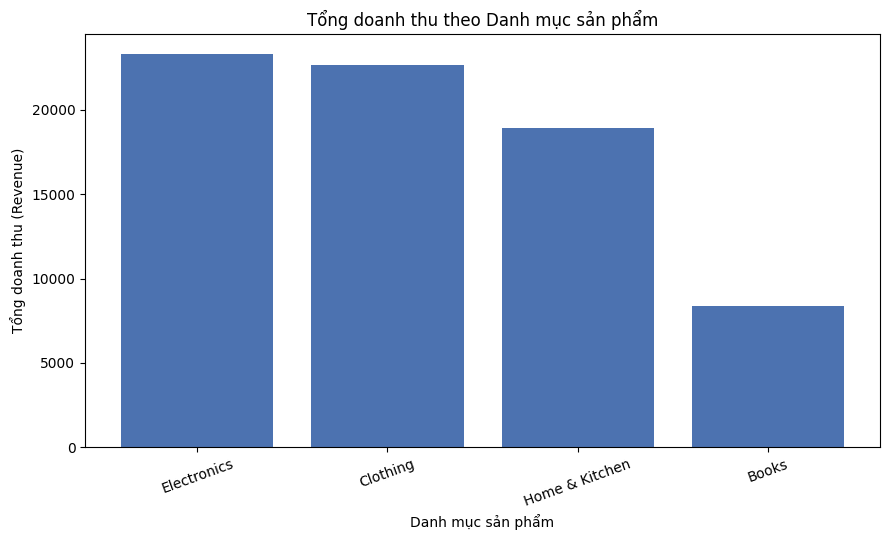

In [42]:
#1. Bar chart: doanh thu theo danh mục sản phẩm
revenue_by_category = df.groupby("Product_Category")["Revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5.5))
plt.bar(revenue_by_category.index, revenue_by_category.values, color="#4C72B0")
plt.title("Tổng doanh thu theo Danh mục sản phẩm")
plt.xlabel("Danh mục sản phẩm")
plt.ylabel("Tổng doanh thu (Revenue)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

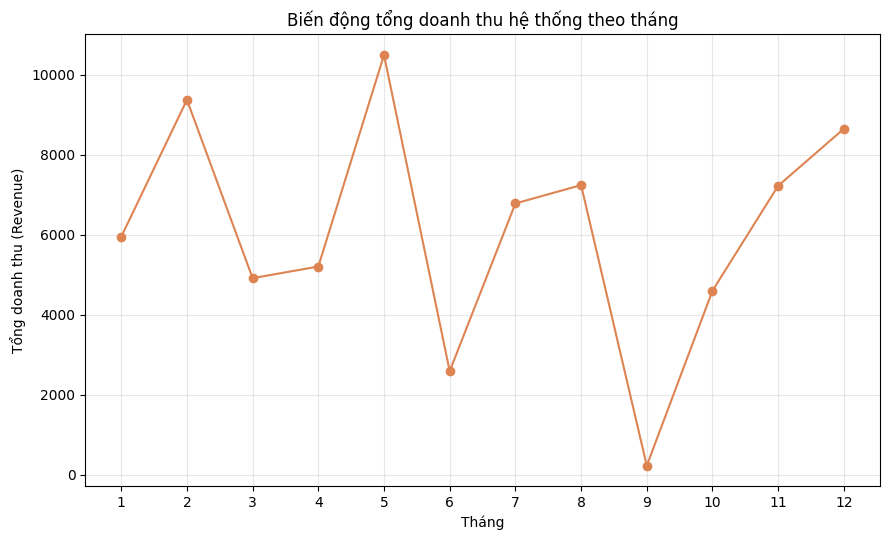

In [43]:
#2. Line chart: biến động doanh thu theo tháng
revenue_by_month = df.groupby("Month")["Revenue"].sum().sort_index()

plt.figure(figsize=(9, 5.5))
plt.plot(revenue_by_month.index, revenue_by_month.values, marker="o", color="#DD8452")
plt.title("Biến động tổng doanh thu hệ thống theo tháng")
plt.xlabel("Tháng")
plt.ylabel("Tổng doanh thu (Revenue)")
plt.xticks(range(1, 13))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()